# Peak overlaps - Figure 1F

In [ ]:
import pandas as pd
import bioframe as bf

import matplotlib.pyplot as plt
from matplotlib_venn import venn3
from matplotlib_venn import venn3_circles

## Define functions

In [2]:
# Function to make 3-way Venn diagram modified from Dmitry (6531/02)
def make_venn3(df1, df2, df3, title1, title2, title3, ax=None):
    reference = bf.merge(pd.concat((df1, df2, df3), ignore_index=True))
    idx1 = set(bf.overlap(reference, df1, how='inner', return_input=False, return_index=True)['index'].to_list())
    idx2 = set(bf.overlap(reference, df2, how='inner', return_input=False, return_index=True)['index'].to_list())
    idx3 = set(bf.overlap(reference, df3, how='inner', return_input=False, return_index=True)['index'].to_list())
    v = venn3((idx1, idx2, idx3), (title1, title2, title3), ax=ax)
    return v, idx1, idx2, idx3 # return both venn-diagram and the sets

## Load peaks of merged technical replicates

In [3]:
RAD21_G2 = bf.read_table("/groups/gerlich/labinfo/Papers/2025_ReplChromConf/analysis/assets/reproducible_peaks/RAD21_WT_G2.reprod_peaks.narrowPeak", schema='narrowPeak')
SOR = bf.read_table("/groups/gerlich/labinfo/Papers/2025_ReplChromConf/analysis/assets/reproducible_peaks/Sororin_WT_G2.reprod_peaks.narrowPeak", schema='narrowPeak')
CTCF = bf.read_table("/groups/gerlich/labinfo/Papers/2025_ReplChromConf/analysis/assets/reproducible_peaks/CTCF_WT_G2.reprod_peaks.narrowPeak", schema='narrowPeak')

## Make Venn diagram

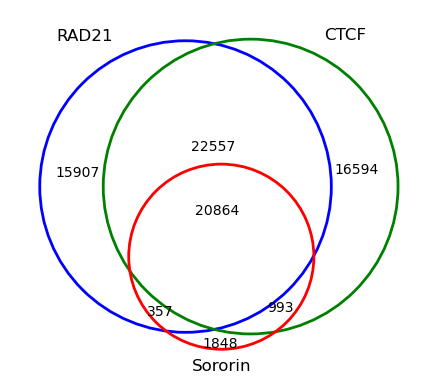

In [4]:
fig, ax = plt.subplots(1, 1)
v, rad21_idx, ctcf_idx, sor_idx = make_venn3(RAD21_G2, CTCF, SOR, 'RAD21', 'CTCF', 'Sororin', ax=ax)

# Set all circles to white fill
for patch in v.patches:
    patch.set_color('white')
    patch.set_alpha(1)

# Customize colors for each circle
c = venn3_circles(subsets=(rad21_idx, ctcf_idx, sor_idx), ax=ax)
c[0].set_edgecolor('blue')
c[1].set_edgecolor('green')
c[2].set_edgecolor('red')